In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
!bq ls my-portfolio-1-490519:movies_project

         tableId          Type    Labels   Time Partitioning   Clustered Fields  
 ----------------------- ------- -------- ------------------- ------------------ 
  movies_metadata         TABLE                                                  
  movies_metadata_clean   TABLE                                                  


In [ ]:
client = bigquery.Client(project="my-portfolio-1-490519")

In [ ]:
from google.cloud import bigquery
client = bigquery.Client(project="my-portfolio-1-490519")

query = """
SELECT *
FROM `my-portfolio-1-490519.movies_project.movies_metadata_clean`
"""

df = client.query(query).to_dataframe()
df.head()

,id,budget,genres,genre_1,genre_2,genre_3,imdb_id,original_language,original_title,popularity,...,count_spoken_language,status,tagline,title,vote_average,vote_count,string_field_24,string_field_25,budget_clean,revenue_clean
0,48382,2000000,[],None,None,None,tt0349159,en,"The Book of Mormon Movie, Volume 1: The Journey",0.08,...,0,Released,"2600 years ago, one family began a remarkable ...","The Book of Mormon Movie, Volume 1: The Journey",5.0,2,None,None,2000000,1672730
1,196859,400000,[],None,None,None,tt0261755,en,Jackpot,0.22,...,0,Released,None,Jackpot,6.0,1,None,None,400000,43719
2,53230,592,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",Romance,Drama,None,tt0016104,en,The Merry Widow,0.29,...,0,Released,None,The Merry Widow,6.5,6,None,None,<NA>,<NA>
3,96239,22361,"[{'id': 10769, 'name': 'Foreign'}, {'id': 35, ...",Foreign,Comedy,Horror,tt1810861,en,Zombadings 1: Patayin sa Shokot si Remington,0.67,...,0,Released,None,Remington and the Curse of the Zombadings,5.3,5,None,None,22361,721651
4,79783,8500000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",Adventure,Drama,Comedy,tt0109368,en,Camilla,0.51,...,0,Released,They went looking for adventure... and found t...,Camilla,4.9,6,None,None,8500000,250993


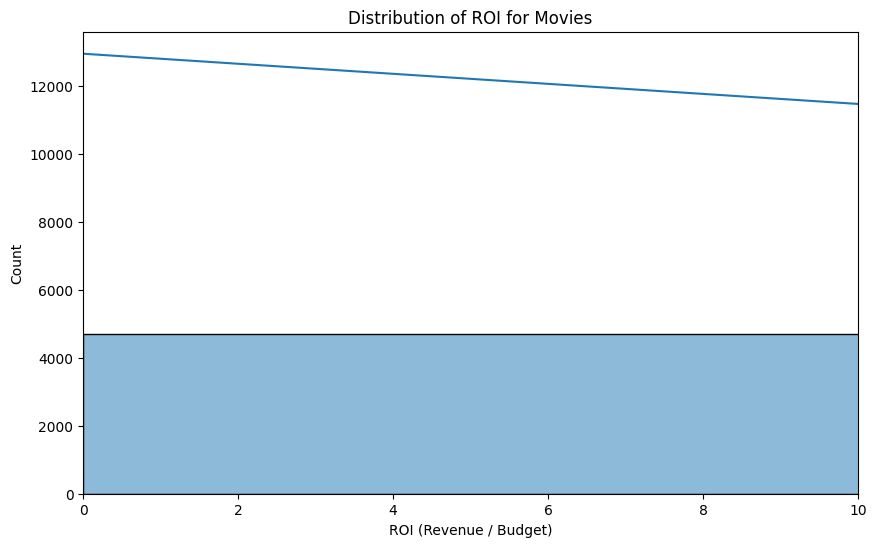

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create ROI column if not already created
df['roi'] = df['revenue_clean'] / df['budget_clean']

plt.figure(figsize=(10,6))
sns.histplot(df['roi'], bins=50, kde=True)
plt.title("Distribution of ROI for Movies")
plt.xlabel("ROI (Revenue / Budget)")
plt.ylabel("Count")
plt.xlim(0, 10)  # prevents extreme outliers from stretching the chart
plt.show()


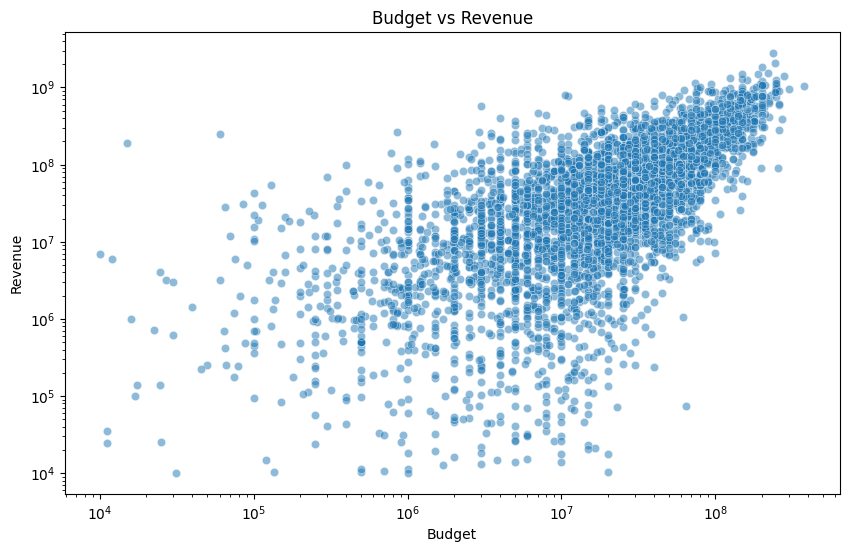

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='budget_clean', y='revenue_clean', alpha=0.5)
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.xscale('log')
plt.yscale('log')
plt.show()

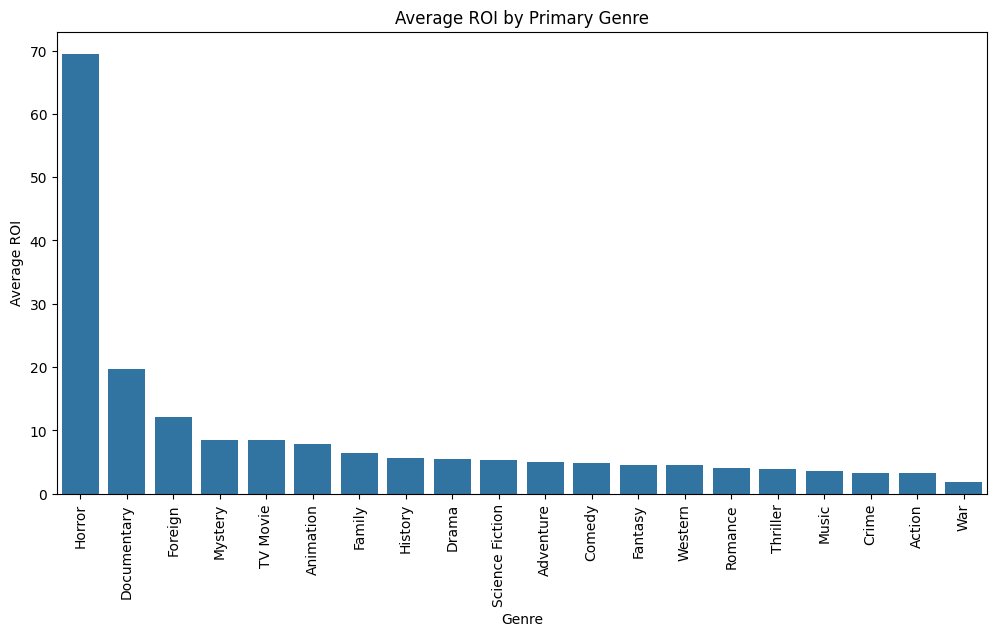

In [ ]:
plt.figure(figsize=(12,6))
genre_roi = df.groupby('genre_1')['roi'].mean().sort_values(ascending=False)

sns.barplot(x=genre_roi.index, y=genre_roi.values)
plt.xticks(rotation=90)
plt.title("Average ROI by Primary Genre")
plt.ylabel("Average ROI")
plt.xlabel("Genre")
plt.show()

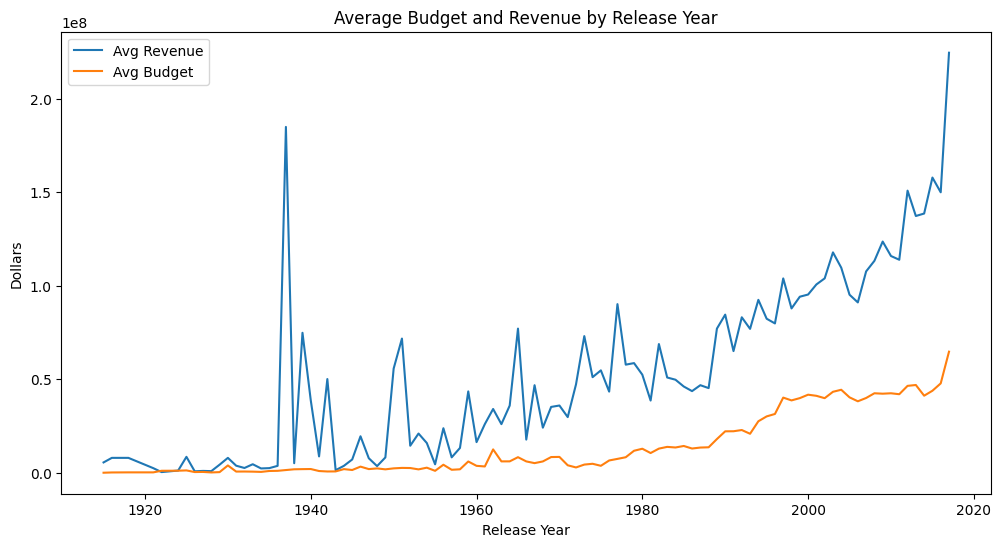

In [ ]:
yearly = df.groupby('release_year').agg({
    'budget_clean': 'mean',
    'revenue_clean': 'mean',
    'roi': 'mean'
}).reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly, x='release_year', y='revenue_clean', label='Avg Revenue')
sns.lineplot(data=yearly, x='release_year', y='budget_clean', label='Avg Budget')
plt.title("Average Budget and Revenue by Release Year")
plt.ylabel("Dollars")
plt.xlabel("Release Year")
plt.legend()
plt.show()

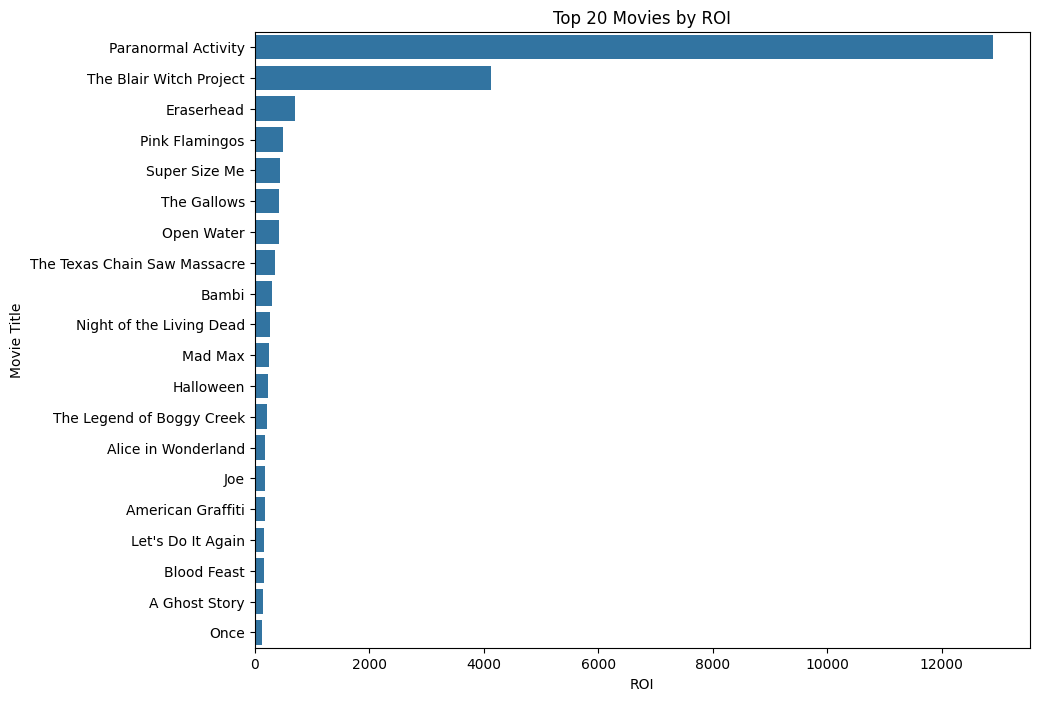

In [ ]:
top20 = df[['title', 'roi']].sort_values(by='roi', ascending=False).head(20)

plt.figure(figsize=(10,8))
sns.barplot(data=top20, x='roi', y='title')
plt.title("Top 20 Movies by ROI")
plt.xlabel("ROI")
plt.ylabel("Movie Title")
plt.show()

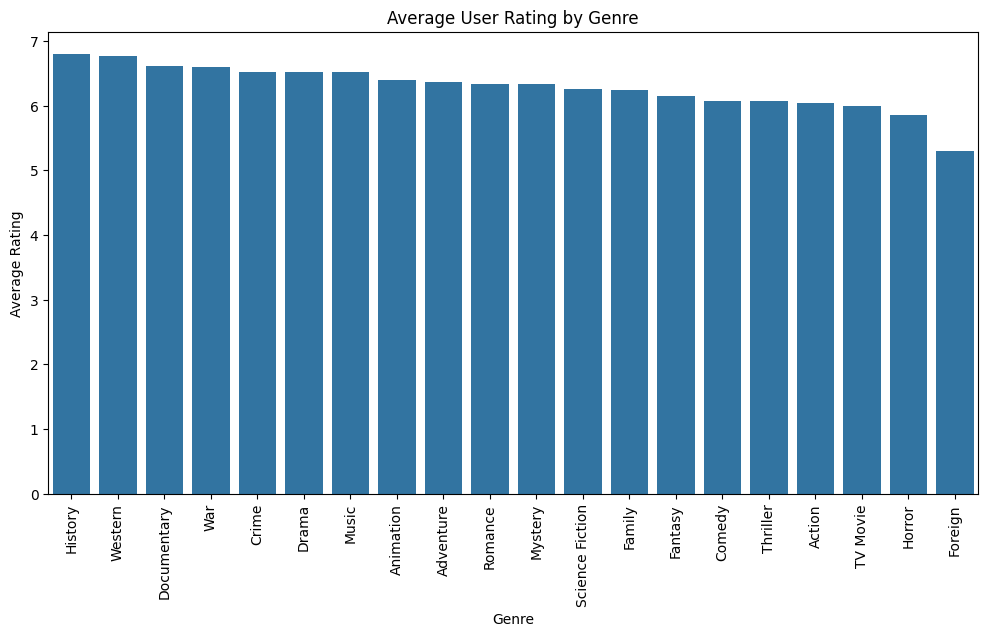

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

genre_ratings = (
    df.groupby('genre_1')['vote_average']
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(x=genre_ratings.index, y=genre_ratings.values)
plt.xticks(rotation=90)
plt.title("Average User Rating by Genre")
plt.ylabel("Average Rating")
plt.xlabel("Genre")
plt.show()

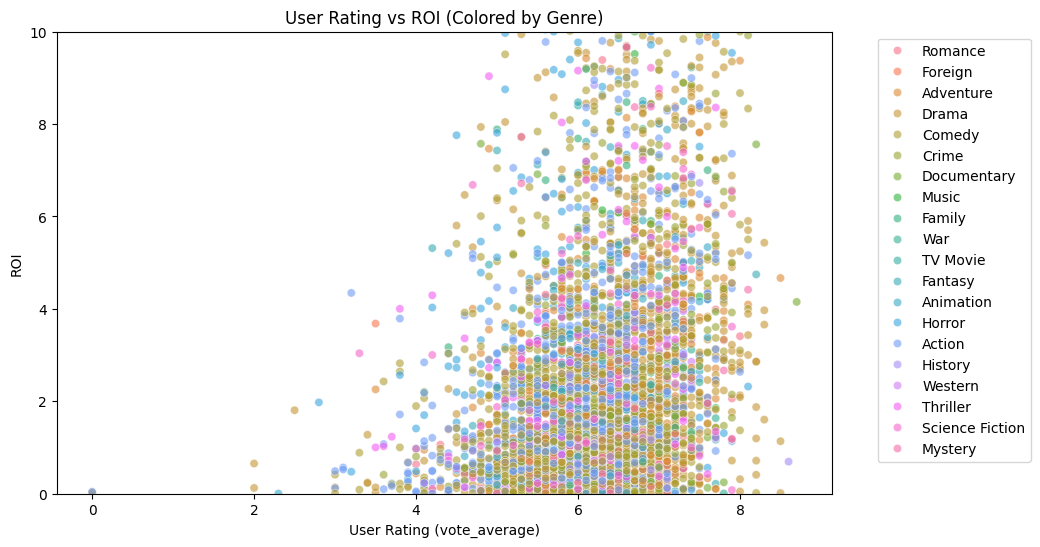

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='vote_average',
    y='roi',
    hue='genre_1',
    alpha=0.6
)

plt.title("User Rating vs ROI (Colored by Genre)")
plt.xlabel("User Rating (vote_average)")
plt.ylabel("ROI")
plt.ylim(0, 10)  # keeps extreme outliers from stretching the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
df[['vote_average', 'roi']].corr()

,vote_average,roi
vote_average,1.000000,0.004044
roi,0.004044,1.000000


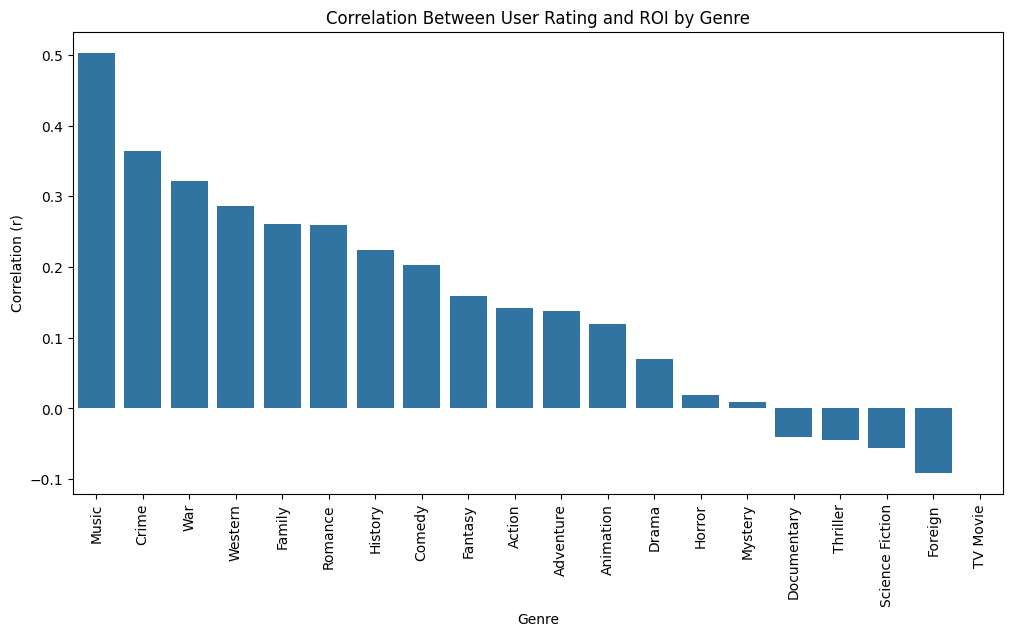

In [ ]:
genre_corr = (
    df.groupby('genre_1')[['vote_average', 'roi']]
      .corr()
      .unstack()
      .iloc[:, 1]  # correlation between vote_average and roi
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_corr.index, y=genre_corr.values)
plt.xticks(rotation=90)
plt.title("Correlation Between User Rating and ROI by Genre")
plt.ylabel("Correlation (r)")
plt.xlabel("Genre")
plt.show()

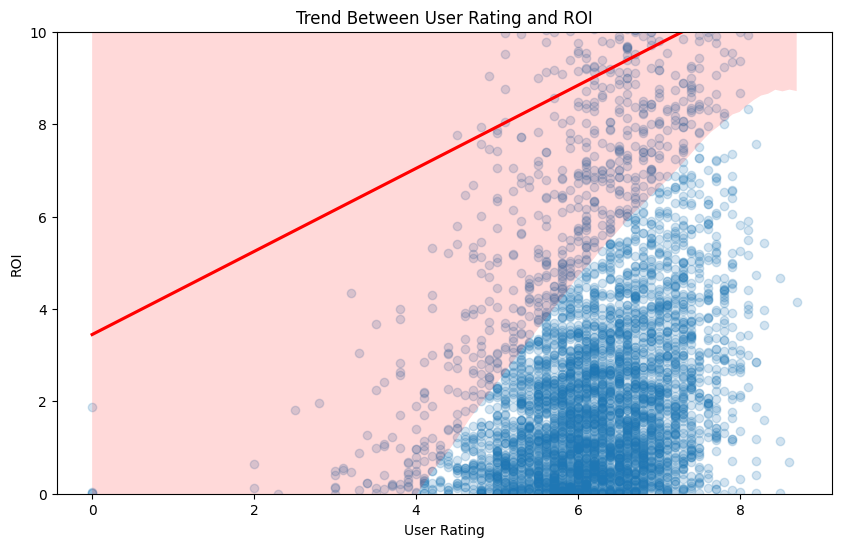

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='vote_average',
    y='roi',
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.title("Trend Between User Rating and ROI")
plt.xlabel("User Rating")
plt.ylabel("ROI")
plt.ylim(0, 10)
plt.show()

In [ ]:
df['decade'] = (df['release_year'] // 10) * 10

In [ ]:
df['roi'] = df['revenue_clean'] / df['budget_clean']

In [ ]:
genre_decade_counts = (
    df.groupby(['decade', 'genre_1'])
      .size()
      .reset_index(name='count')
)

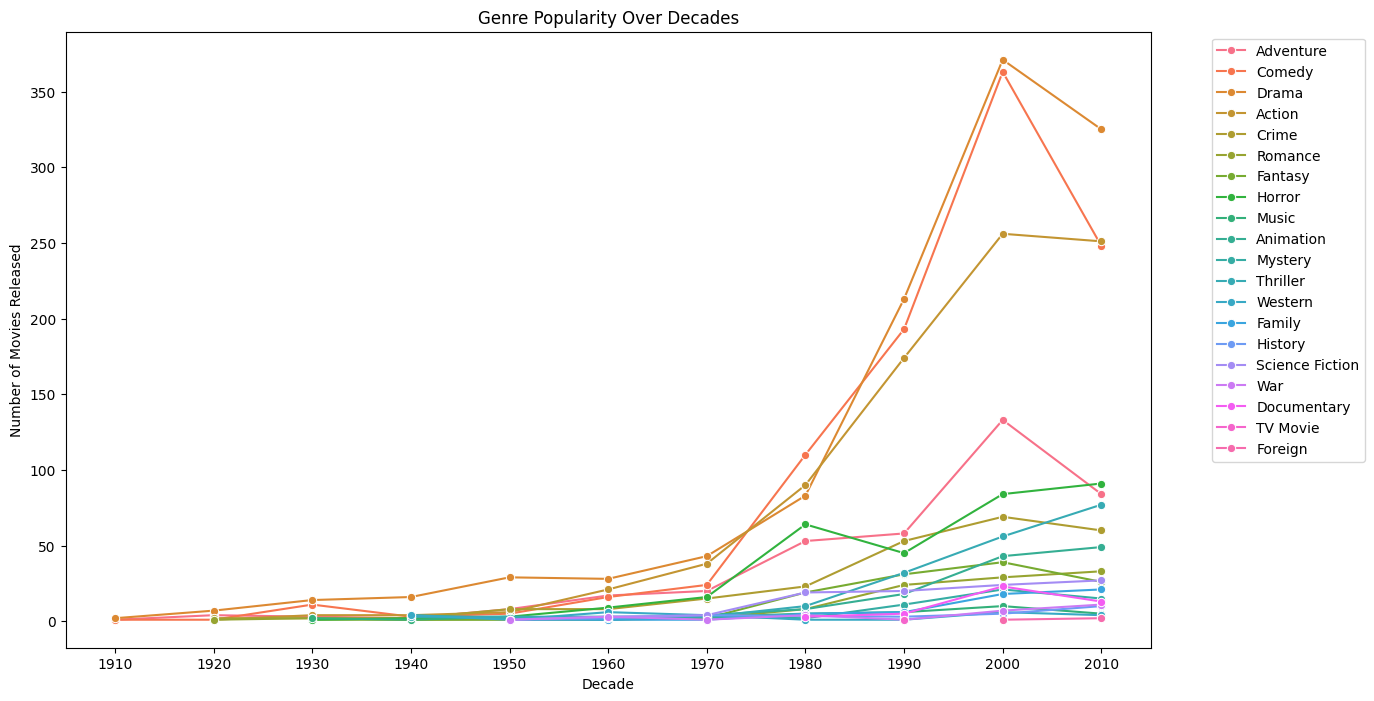

In [ ]:
plt.figure(figsize=(14,8))

sns.lineplot(
    data=genre_decade_counts,
    x='decade',
    y='count',
    hue='genre_1',
    marker='o'
)

plt.title("Genre Popularity Over Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Movies Released")
plt.xticks(sorted(df['decade'].unique()))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

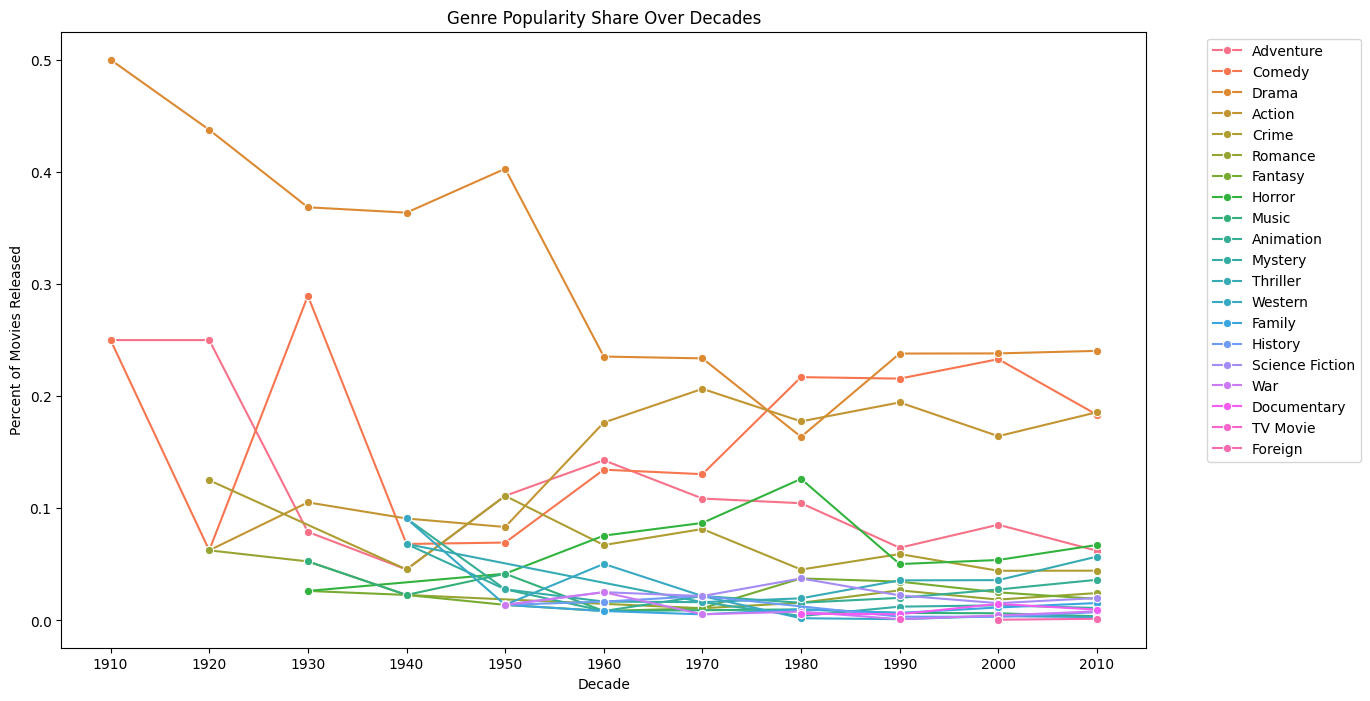

In [ ]:
decade_totals = genre_decade_counts.groupby('decade')['count'].transform('sum')
genre_decade_counts['percent'] = genre_decade_counts['count'] / decade_totals

plt.figure(figsize=(14,8))

sns.lineplot(
    data=genre_decade_counts,
    x='decade',
    y='percent',
    hue='genre_1',
    marker='o'
)

plt.title("Genre Popularity Share Over Decades")
plt.xlabel("Decade")
plt.ylabel("Percent of Movies Released")
plt.xticks(sorted(df['decade'].unique()))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
df['roi'] = df['revenue_clean'] / df['budget_clean']

# Drop rows where ROI is missing
df = df.dropna(subset=['roi'])

df['hit'] = (df['roi'] >= 1).astype(int)

/tmp/ipykernel_228/44409754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['roi'] = df['revenue_clean'] / df['budget_clean']


In [ ]:
df['roi'] = df['revenue_clean'] / df['budget_clean']
df['hit'] = (df['roi'] >= 1).astype(int)

In [ ]:
model_df = df[['budget_clean', 'popularity', 'vote_average', 'vote_count',
               'runtime_minutes', 'genre_1', 'release_year', 'hit']].dropna()

In [ ]:
from sklearn.model_selection import train_test_split

X = model_df.drop('hit', axis=1)
y = model_df['hit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import pandas as pd

In [ ]:
model_df.columns

Index(['budget_clean', 'popularity', 'vote_average', 'vote_count',
       'runtime_minutes', 'release_year', 'hit', 'genre_1_Adventure',
       'genre_1_Animation', 'genre_1_Comedy', 'genre_1_Crime',
       'genre_1_Documentary', 'genre_1_Drama', 'genre_1_Family',
       'genre_1_Fantasy', 'genre_1_Foreign', 'genre_1_History',
       'genre_1_Horror', 'genre_1_Music', 'genre_1_Mystery', 'genre_1_Romance',
       'genre_1_Science Fiction', 'genre_1_TV Movie', 'genre_1_Thriller',
       'genre_1_War', 'genre_1_Western'],
      dtype='object')

In [ ]:
model_df = df[['budget_clean', 'popularity', 'vote_average', 'vote_count',
               'runtime_minutes', 'genre_1', 'release_year', 'hit']].dropna()

In [ ]:
model_df.columns

Index(['budget_clean', 'popularity', 'vote_average', 'vote_count',
       'runtime_minutes', 'genre_1', 'release_year', 'hit'],
      dtype='object')

In [ ]:
import pandas as pd

model_df = pd.get_dummies(model_df, columns=['genre_1'], drop_first=True)

In [ ]:
X_train.columns

Index(['budget_clean', 'popularity', 'vote_average', 'vote_count',
       'runtime_minutes', 'genre_1', 'release_year'],
      dtype='object')

In [ ]:
model_df = df[['budget_clean', 'popularity', 'vote_average', 'vote_count',
               'runtime_minutes', 'genre_1', 'release_year', 'hit']].dropna()

In [ ]:
import pandas as pd

model_df = pd.get_dummies(model_df, columns=['genre_1'], drop_first=True)

In [ ]:
model_df.columns

Index(['budget_clean', 'popularity', 'vote_average', 'vote_count',
       'runtime_minutes', 'release_year', 'hit', 'genre_1_Adventure',
       'genre_1_Animation', 'genre_1_Comedy', 'genre_1_Crime',
       'genre_1_Documentary', 'genre_1_Drama', 'genre_1_Family',
       'genre_1_Fantasy', 'genre_1_Foreign', 'genre_1_History',
       'genre_1_Horror', 'genre_1_Music', 'genre_1_Mystery', 'genre_1_Romance',
       'genre_1_Science Fiction', 'genre_1_TV Movie', 'genre_1_Thriller',
       'genre_1_War', 'genre_1_Western'],
      dtype='object')

In [ ]:
X = model_df.drop('hit', axis=1)
y = model_df['hit']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.columns

Index(['budget_clean', 'popularity', 'vote_average', 'vote_count',
       'runtime_minutes', 'release_year', 'genre_1_Adventure',
       'genre_1_Animation', 'genre_1_Comedy', 'genre_1_Crime',
       'genre_1_Documentary', 'genre_1_Drama', 'genre_1_Family',
       'genre_1_Fantasy', 'genre_1_Foreign', 'genre_1_History',
       'genre_1_Horror', 'genre_1_Music', 'genre_1_Mystery', 'genre_1_Romance',
       'genre_1_Science Fiction', 'genre_1_TV Movie', 'genre_1_Thriller',
       'genre_1_War', 'genre_1_Western'],
      dtype='object')

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

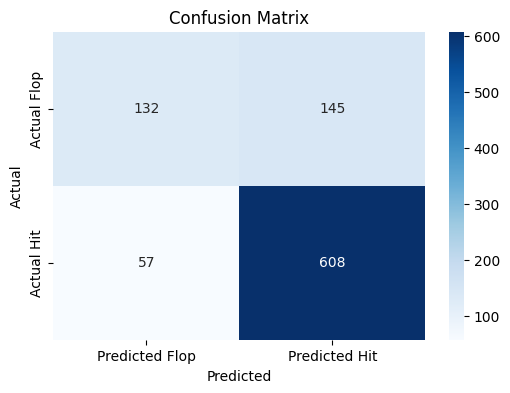

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Flop', 'Predicted Hit'],
            yticklabels=['Actual Flop', 'Actual Hit'])

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

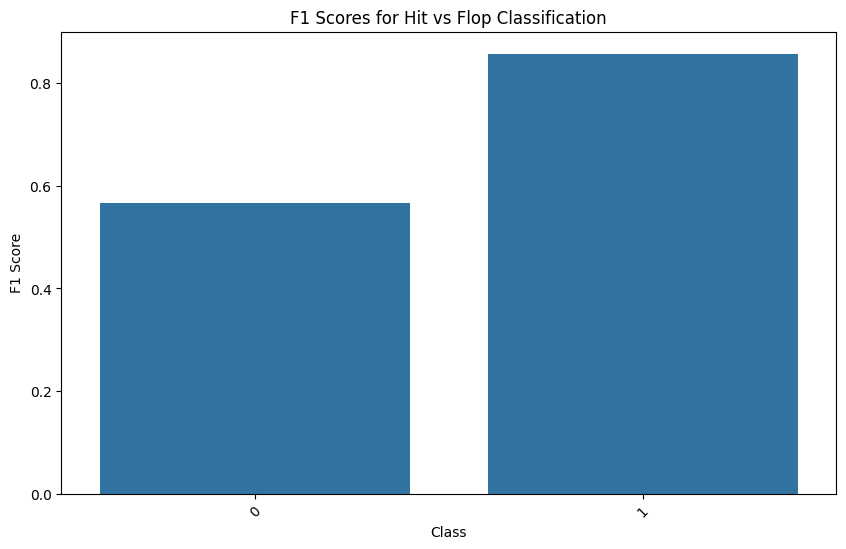

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10,6))
sns.barplot(x=report_df.index[:-3], y=report_df['f1-score'][:-3])
plt.xticks(rotation=45)
plt.title("F1 Scores for Hit vs Flop Classification")
plt.ylabel("F1 Score")
plt.xlabel("Class")
plt.show()

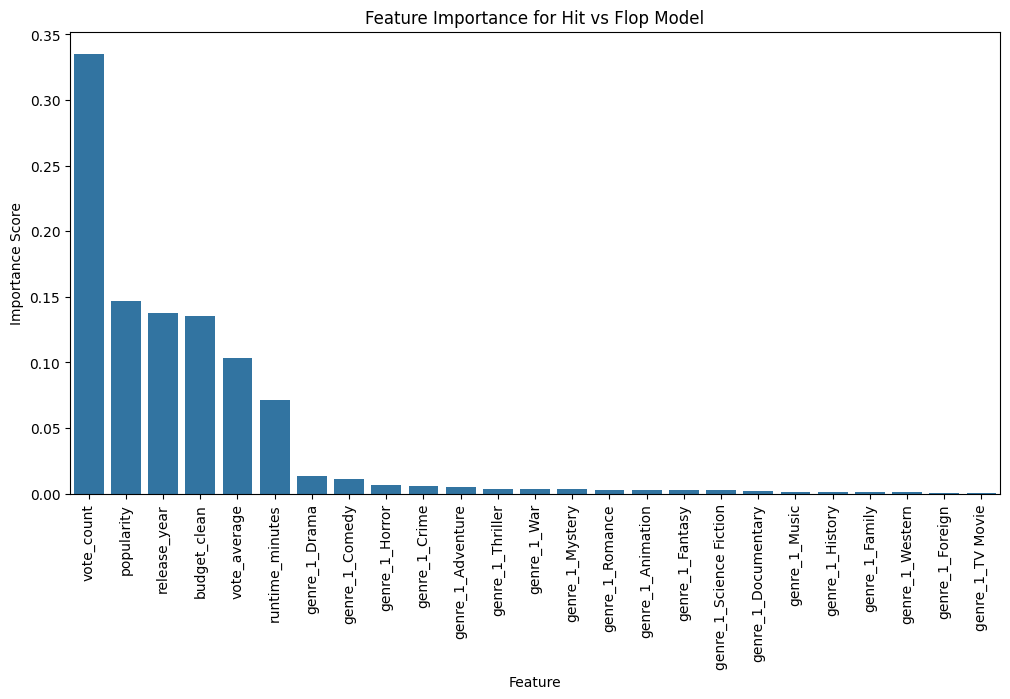

In [ ]:
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
sns.barplot(x=X.columns[indices], y=importances[indices])
plt.xticks(rotation=90)
plt.title("Feature Importance for Hit vs Flop Model")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.show()

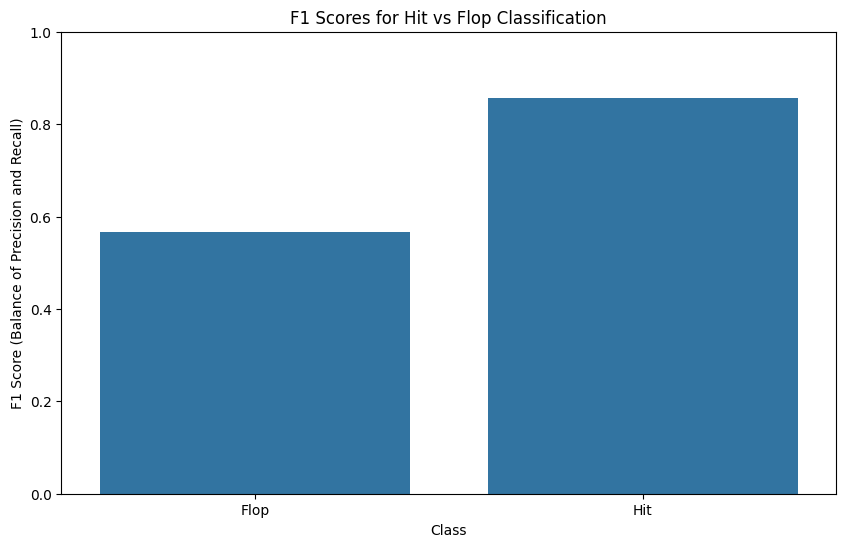

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate classification report as a DataFrame
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Rename the index values for clarity
report_df = report_df.rename(index={'0': 'Flop', '1': 'Hit'})

plt.figure(figsize=(10,6))

# Plot only the classes (exclude accuracy, macro avg, weighted avg)
sns.barplot(
    x=report_df.index[:2],
    y=report_df['f1-score'][:2]
)

plt.xticks(rotation=0)
plt.title("F1 Scores for Hit vs Flop Classification")

# More descriptive y-axis label
plt.ylabel("F1 Score (Balance of Precision and Recall)")

plt.xlabel("Class")
plt.ylim(0, 1)  # optional: keeps scale consistent
plt.show()


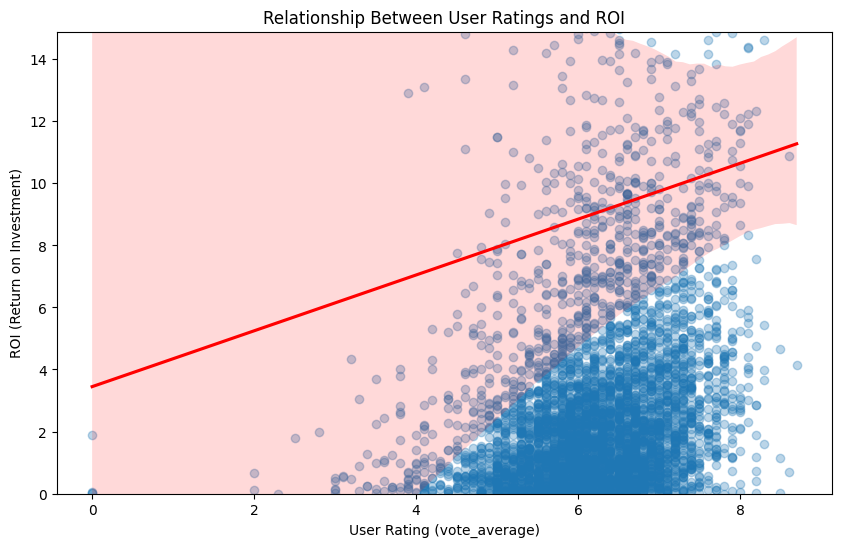

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='vote_average',
    y='roi',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Relationship Between User Ratings and ROI")
plt.xlabel("User Rating (vote_average)")
plt.ylabel("ROI (Return on Investment)")
plt.ylim(0, df['roi'].quantile(0.95))  # trims extreme outliers for clarity
plt.show()


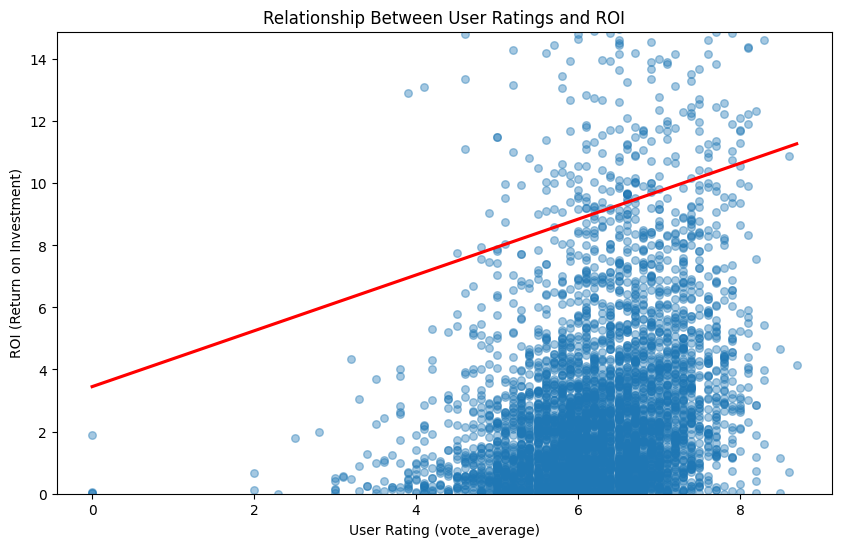

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='vote_average',
    y='roi',
    scatter_kws={'alpha':0.4, 's':30},
    line_kws={'color':'red'},
    ci=None  # removes the confidence band
)

plt.title("Relationship Between User Ratings and ROI")
plt.xlabel("User Rating (vote_average)")
plt.ylabel("ROI (Return on Investment)")
plt.ylim(0, df['roi'].quantile(0.95))
plt.show()


(0.0, 8.74781341107872)

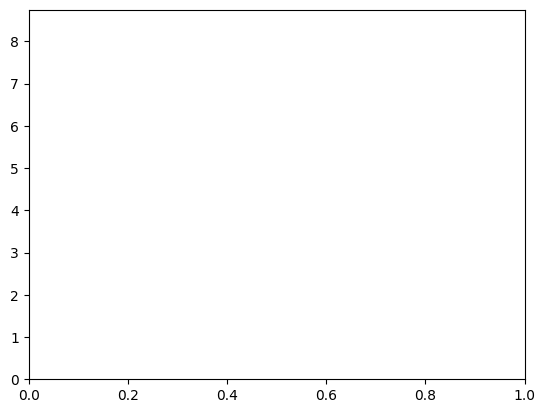

In [ ]:
plt.ylim(0, df['roi'].quantile(0.90))

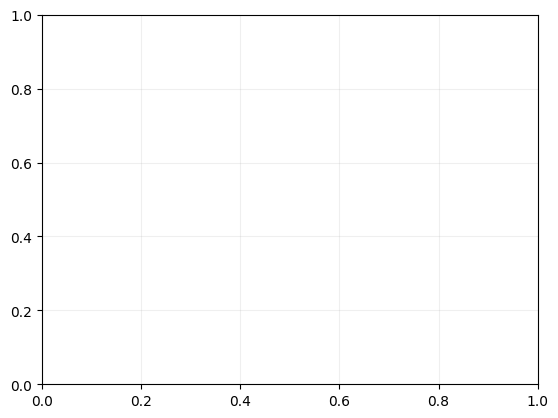

In [ ]:
plt.grid(alpha=0.2)

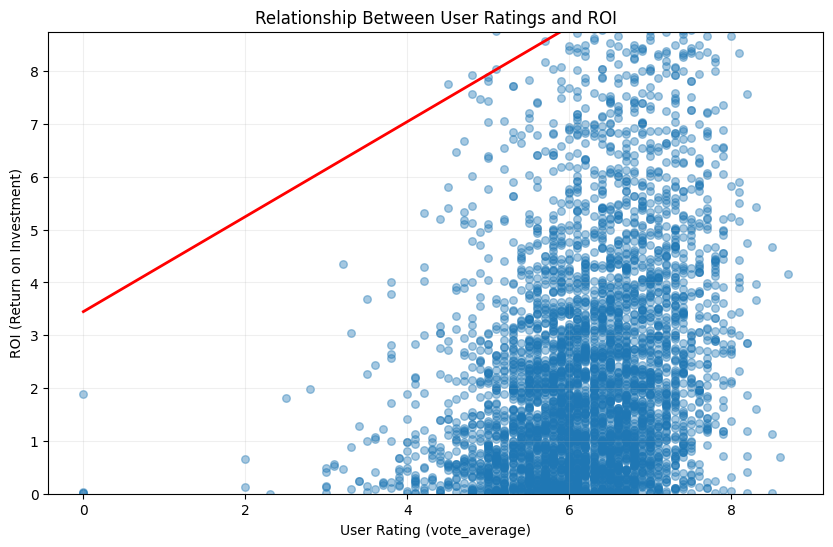

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='vote_average',
    y='roi',
    scatter_kws={'alpha':0.4, 's':30},
    line_kws={'color':'red', 'linewidth':2},
    ci=None
)

plt.title("Relationship Between User Ratings and ROI")
plt.xlabel("User Rating (vote_average)")
plt.ylabel("ROI (Return on Investment)")
plt.ylim(0, df['roi'].quantile(0.90))
plt.grid(alpha=0.2)
plt.show()
